In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    ComputeAll,
    RobustRelativeProcrustesDistance,
)

from src.helper_functions._metrics_helper import rv_coefficient, rv_coefficient_adjusted, cvm_stat_multivariate, observed_cvm_dependency

from src.methods import (
    PermutationTest,
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest,
    QAP,
    ObservedCVM
)
from src.solvers.binary_network import MLE_logistic
from src.solvers.MaMa_uuuuu import pgd_fit_wrapper, pgd_fit
from src.solvers.weighted_network import MLE_gaussian, ASE
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
from src.helper_functions.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats
from src.helper_functions.plot_functions import visualise_latent
from functools import partial

In [2]:
m = BernoulliNetwork(n=100, k=10, rho=-.95, marginals='cauchy', center_latent=False, self_loops=False)
data = m.generate()

# plt.hist((data['Z']).flatten())
# out = MLE_gaussian(data['A'], k=3)
# RobustRelativeProcrustesDistance()({'estimated_latent':out[0], 'true_latent':data['Z']})
# plt.hist((out[0]).flatten())


In [3]:
A = data['A']
B = data['B']


0.5376712914003388


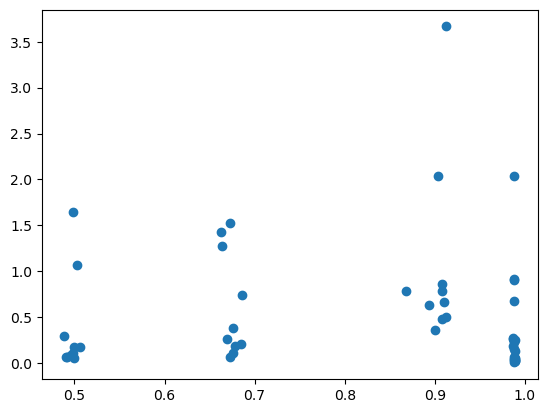

In [4]:
out = []
density = []
marginal = ['uniform -2 -1', 'uniform -1 1', 'uniform 0 1', 'uniform 0 2', 'uniform 1 2']
for i in range(50):
    m = BernoulliNetwork(n=100, k=3, rho=0, marginals=marginal[i % 5], center_latent=False, self_loops=False)
    data = m.generate()
    density.append(data['A'].sum()/data['A'].size)

    out.append(observed_cvm_dependency(data['A'], data['B']))

print(np.mean(out))
plt.scatter(density, out)

In [82]:
nsim = 5
n = [50, 150, 250]
k = [2]
rho = [0.3]
alpha = [0.05]
marginals = ['gaussian', 'cauchy', 'uniform -2 2']
edge_var = [1]

method = [
    # partial(RVPermutationTest, permutation_type="latent"),
    # partial(RVPermutationTest, permutation_type="observed"),
    # LLKRatioTest,
    # QAP,
    # DiffusionCorrelation,
    # partial(CanonicalCorrelationTest, permutation_type="latent"),
    partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=3)),
    partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=2)),
    partial(ObservedCVM, test_function=partial(observed_cvm_dependency, degree=1)),
    # FitIndependent
]

npermutations = [100]
metrics = [ComputeAll()]
approximation = ["F-distr"]

solver = partial(MLE_gaussian, k=2)

model = partial(BernoulliNetwork, center_latent=True, self_loops=False)

setup = [
    (partial(BernoulliNetwork, center_latent=True, self_loops=False), partial(MLE_gaussian, k=2)),
    (partial(GaussianNetwork, center_latent=True, self_loops=False), partial(MLE_gaussian, k=2)),
]

rng = np.random.default_rng(0)    

param_names = [
    "setup",
    "method",
    "n",
    "k",
    "rho",
    "alpha",
    "marginals",
    "edge_var",
    "approximation",
    "npermutations"
]

param_values = product(
    setup, method, n, k, rho, alpha, marginals, edge_var, approximation, npermutations
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

out = pd.DataFrame(out)

Running scenarios: 100%|██████████| 135/135 [01:02<00:00,  2.15it/s]


In [83]:
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x.get("edge_var", "NA"))
out["approximation"] = out["args"].apply(lambda x: x.get("approximation", "NA"))
out["dgp"] = out["args"].apply(lambda x: x["setup"][0].func.__name__)
out["solver"] = out["args"].apply(lambda x: x["setup"][1].func.__name__)
out['rho'] = out["args"].apply(lambda x: x.get("rho", "NA"))

out["method"] = out["args"].apply(lambda x: x.get("method_name", "NA"))

out["marginals"] = out["args"].apply(lambda x: x.get("marginals", "NA"))

In [84]:
# Extract degree
out["degree"] = out["args"].apply(
    lambda x: x["method"].keywords["test_function"].keywords["degree"]
)

In [85]:
out["FalseRejection"] = out["ComputeAll"].apply(lambda x: x["FalseRejection"])
out["TrueRejection"] = out["ComputeAll"].apply(lambda x: x["TrueRejection"])
out["Rejection"] = out["ComputeAll"].apply(lambda x: x["Rejection"])
# out['RelativeFrobeniusNorm_x'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_x"])
# out['ProcrustesDistance_x'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_x"])
# out['RelativeFrobeniusNorm_z'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_z"])
# out['ProcrustesDistance_z'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_z"])

In [86]:
results_gaussian = out[out["dgp"] == "GaussianNetwork"]
results_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

results_null_gaussian = results_gaussian[results_gaussian["rho"] == 0]
results_null_bernoulli = results_bernoulli[results_bernoulli["rho"] == 0]

results_null_gaussian_rv = results_null_gaussian[
    results_null_gaussian["method"] == "RVPermutationTest"
]
results_null_gaussian_llk = results_null_gaussian[
    results_null_gaussian["method"] == "LLKRatioTest"
]

results_05_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.5)
]

results_05_bernoulli = out[
    (out['dgp'] == "BernoulliNetwork") & (out['rho'] == 0.5)
]

results_03_bernoulli = out[
    (out['dgp'] == "BernoulliNetwork") & (out['rho'] == 0.3)
]

results_03_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.3)
]

In [87]:
# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )

# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )
# agg_gaussian_z = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_x = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_z = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )

# agg_gaussian_null = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )

agg_05_gaussian = aggregate_results(
    results_05_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "degree", "method"],
)

agg_bernoulli_null = aggregate_results(
    results_null_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

agg_05_bernoulli = aggregate_results(
    results_05_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "degree", "method"],
)

agg_03_bernoulli = aggregate_results(
    results_03_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "degree", "method"],
)
agg_03_gaussian = aggregate_results(
    results_03_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "degree", "method"],
)

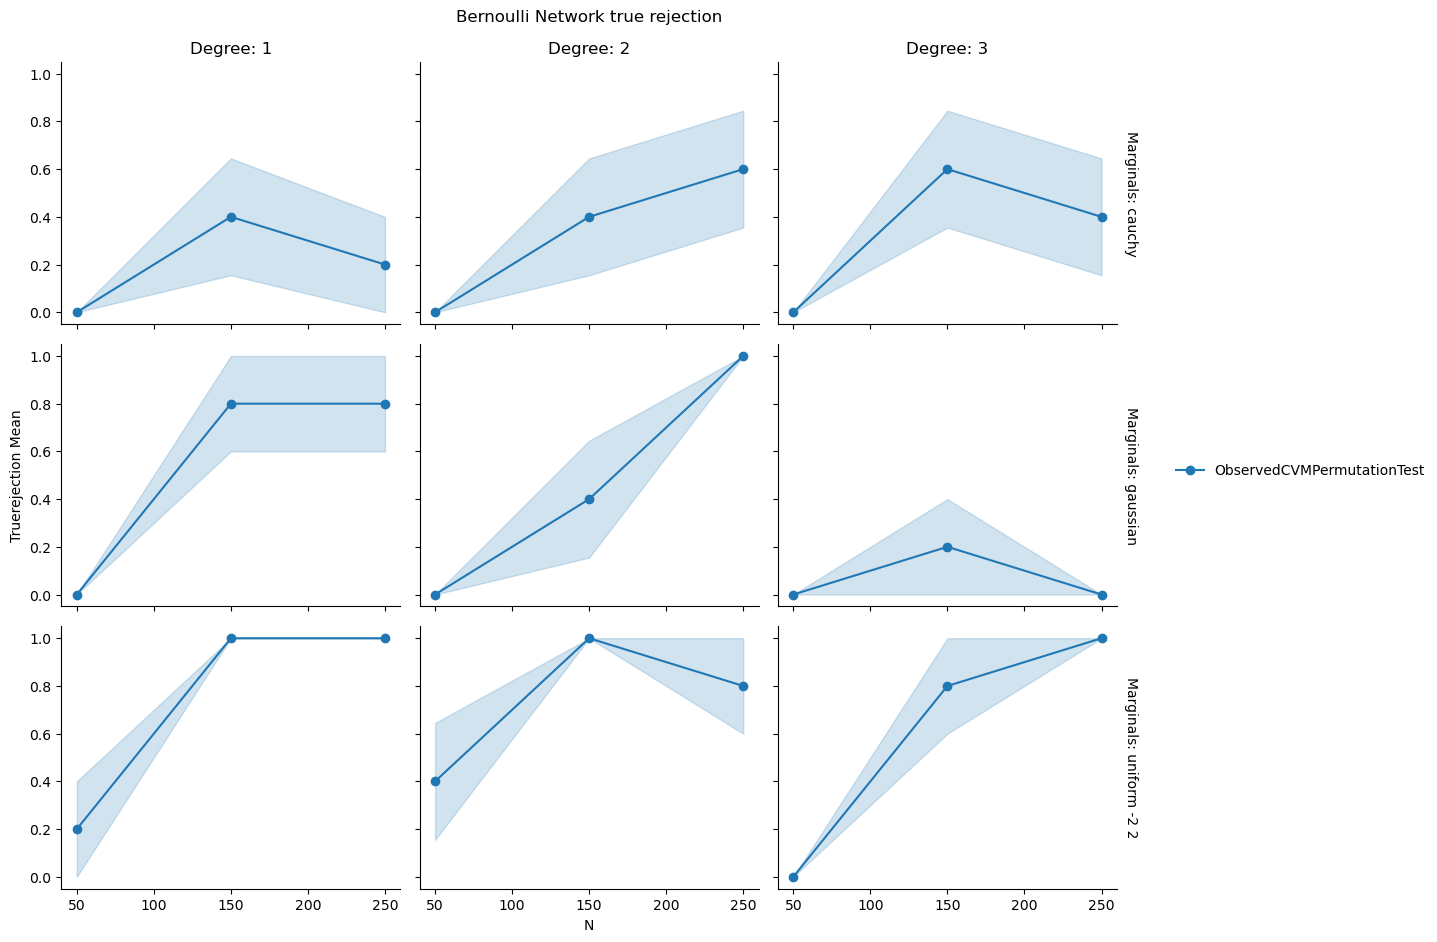

In [91]:
plot_grid(
    grouped_stats=agg_03_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "degree", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network true rejection",
)

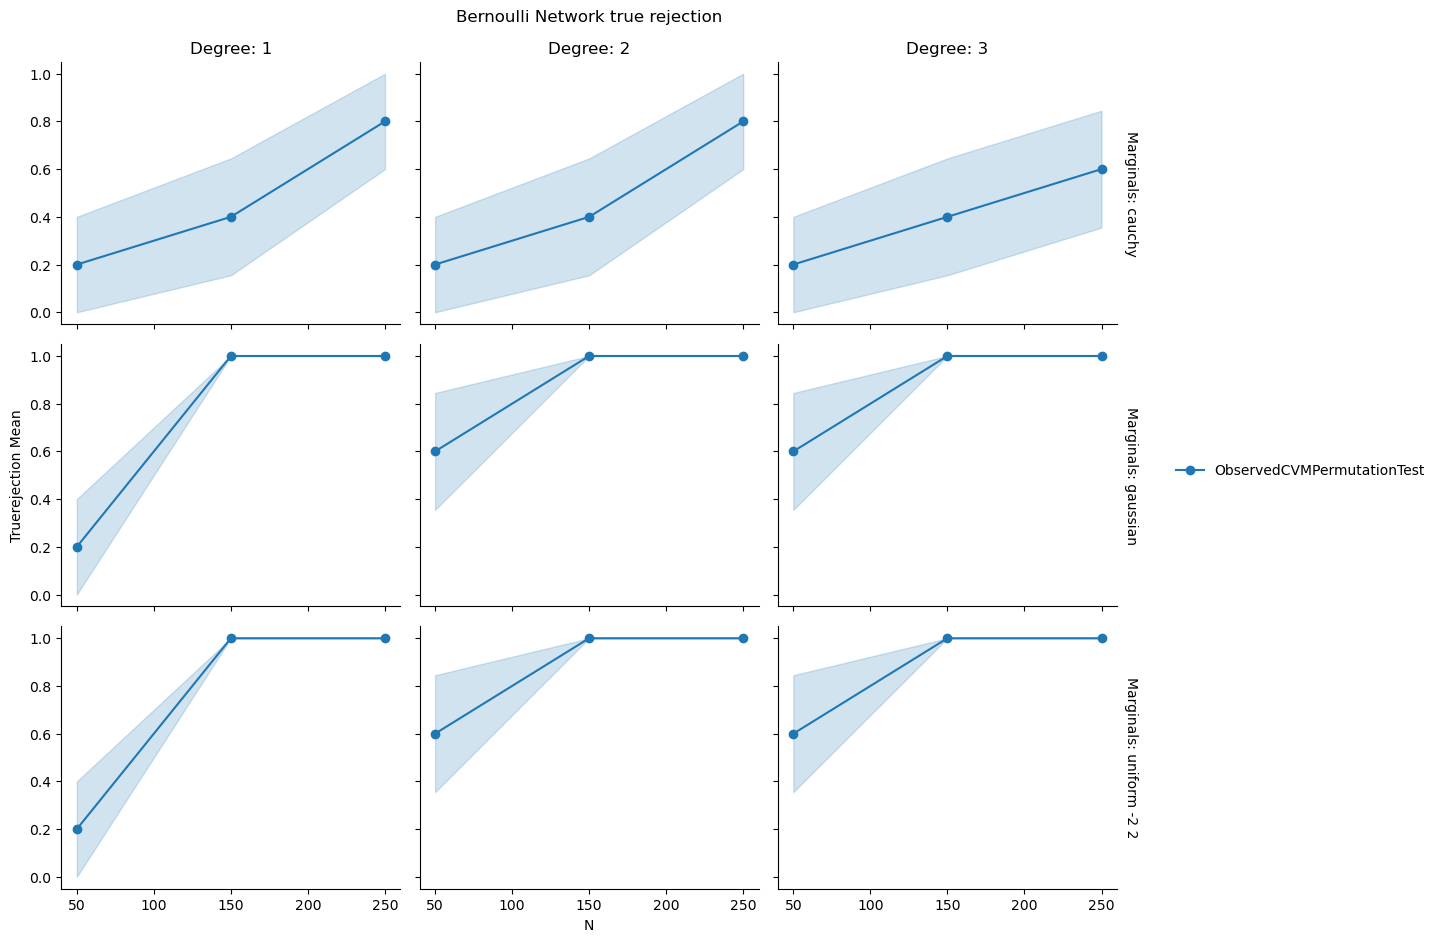

In [ ]:
plot_grid(
    grouped_stats=agg_03_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "degree", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network true rejection",
)

In [ ]:
1/0

ZeroDivisionError: division by zero

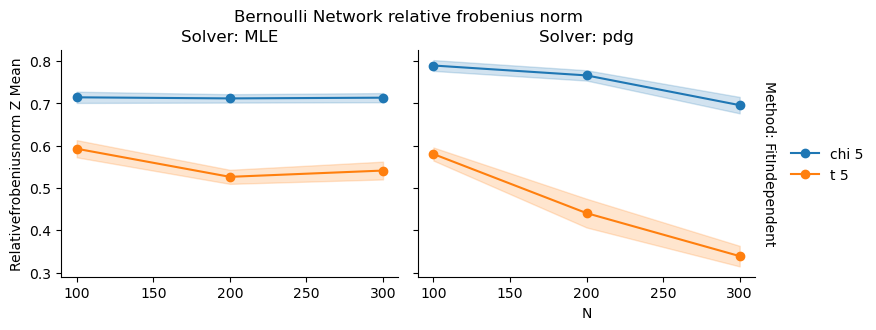

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_bernoulli_null[agg_bernoulli_null['marginals']!= 'beta 2 5'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

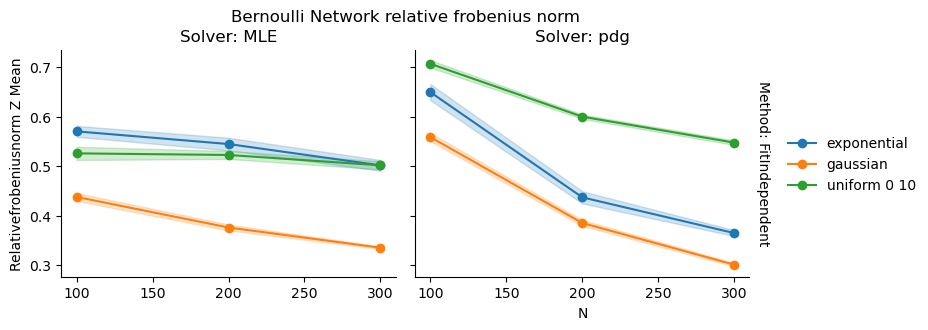

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["marginals", "solver", "method"],
    height=3,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=True,
    title="Bernoulli Network relative frobenius norm",
)

In [ ]:
plot_grid(
    grouped_stats=agg_gaussian_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Gaussian Network false rejection rate",
)

plot_grid(
    grouped_stats=agg_bernoulli_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="Bernoulli Network false rejection rate",
)

KeyError: 'solver'

: 

: 

### Logistic rdpg solver

In [ ]:
nsim = 100
n = 100
k = 2
rho = 0
false_rej = 0
for i in range(nsim):
    rng = np.random.default_rng()

    md = GaussianNetwork(n=n, k=k, rho=rho, rng=rng, edge_var=1)

    A, B, X, Z = md.generate()

    method = RVPermutationTest(rng=rng, shrink=0, solver=MLE_gaussian, rho=rho)

    method.fit(A, B=B, X=X, Z=Z, rv_coefficient_function=rv_coefficient_adjusted)

    estimated = method.get_estimated()
    truth = method.get_truth()

    false_rej += FalseRejection()(estimated, truth)

print(false_rej / nsim)

0.03


: 

: 

### Testing Logistic RDPG

In [ ]:
nsim = 200
n = [10, 25, 50, 100, 200, 300]
k = [2, 5]
rho = [0, 0.1]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{"a": 2, "b": 5}]
marginal_z_params = [{"a": 2, "b": 5}]
solver = [MLE_gaussian]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork]
methods = [RVPermutationTest]
metrics = [FalseRejection(), TrueRejection(), Rejection()]
rv_coefficient_function = [rv_coefficient_adjusted, rv_coefficient]

rng = np.random.default_rng(1)

param_names = [
    "dgp",
    "method",
    "n",
    "k",
    "rho",
    "alpha",
    "marginal_z",
    "marginal_x",
    "edge_var",
    "solver",
    "rv_coefficient_function",
]

param_values = product(
    dgp,
    methods,
    n,
    k,
    rho,
    alpha,
    marginal_z,
    marginal_x,
    edge_var,
    solver,
    rv_coefficient_function,
)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

Running scenarios: 100%|██████████| 28800/28800 [00:57<00:00, 498.96it/s]


: 

: 

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))
out["rho"] = out["args"].apply(lambda x: x["rho"])
out["method"] = out["args"].apply(lambda x: str(x["method"].__name__))
out["rv_coefficient_function"] = out["args"].apply(
    lambda x: str(x["rv_coefficient_function"].__name__)
)

: 

: 

In [ ]:
out_null = out[out["rho"] == 0]
out_alt = out[out["rho"] != 0]

: 

: 

In [ ]:
agg_out_null = aggregate_results(
    out_null,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)
agg_out_alt = aggregate_results(
    out_alt,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "rv_coefficient_function"],
)

: 

: 

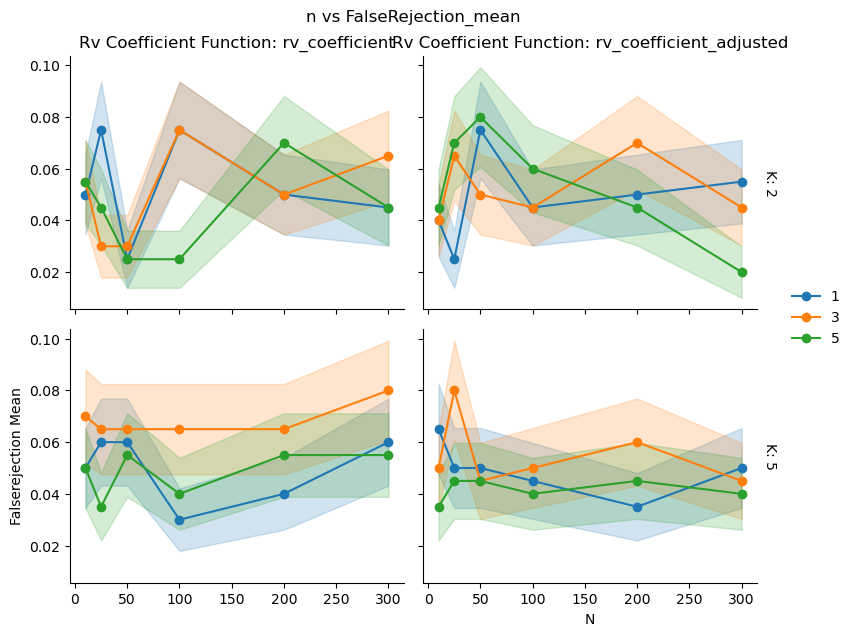

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_null,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
)

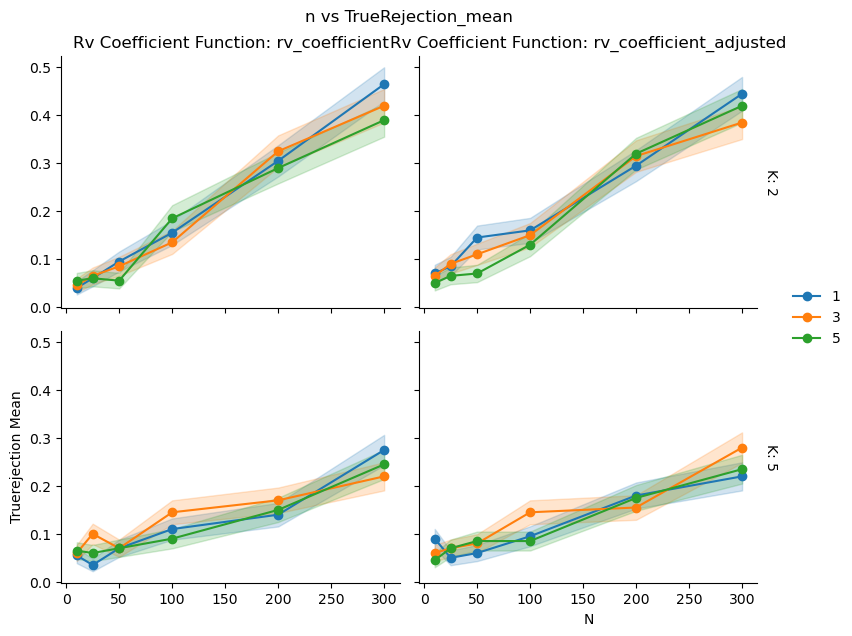

: 

: 

In [ ]:
plot_grid(
    grouped_stats=agg_out_alt,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["edge_var", "rv_coefficient_function", "k"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
)

In [ ]:
1 / 0

ZeroDivisionError: division by zero

: 

: 

## NORM results

In [ ]:
out = pd.DataFrame(out)
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x["edge_var"])

out["dgp"] = out["args"].apply(lambda x: str(x["dgp"].__name__))

out["RelativeFrobeniusNorm_z"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[1])
out["RelativeFrobeniusNorm_x"] = out["RelativeFrobeniusNorm"].apply(lambda x: x[0])

out["solver"] = out["args"].apply(lambda x: str(x["solver"].__name__))

: 

: 

In [ ]:
out_gaussian = out[out["dgp"] == "GaussianNetwork"]
out_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

out_x_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)
out_x_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_z"]
)

out_z_gaussian = out_gaussian.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)
out_z_bernoulli = out_bernoulli.drop(
    columns=["RelativeFrobeniusNorm", "RelativeFrobeniusNorm_x"]
)

out_x_gaussian_ase = out_x_gaussian[out_x_gaussian["solver"] == "ASE"]
out_x_gaussian_mle = out_x_gaussian[out_x_gaussian["solver"] == "MLE_gaussian"]
out_x_gaussian_mle_logistic = out_x_gaussian[out_x_gaussian["solver"] == "MLE_logistic"]

out_x_bernoulli_ase = out_x_bernoulli[out_x_bernoulli["solver"] == "ASE"]
out_x_bernoulli_mle = out_x_bernoulli[out_x_bernoulli["solver"] == "MLE_gaussian"]
out_x_bernoulli_mle_logistic = out_x_bernoulli[
    out_x_bernoulli["solver"] == "MLE_logistic"
]

: 

: 

In [ ]:
agg_out_z_gaussian = aggregate_results(
    out_z_gaussian,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_gaussian = aggregate_results(
    out_x_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_x_bernoulli = aggregate_results(
    out_x_bernoulli,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_out_z_bernoulli = aggregate_results(
    out_z_bernoulli,
    y_axis="RelativeFrobeniusNorm_z",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

: 

: 

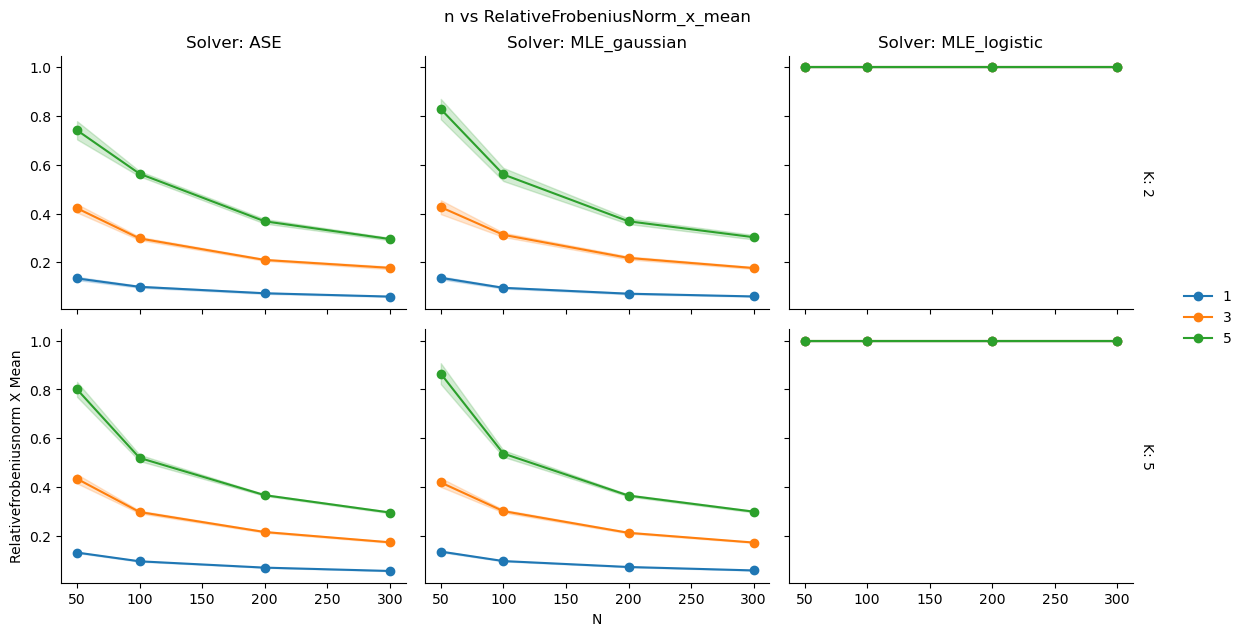

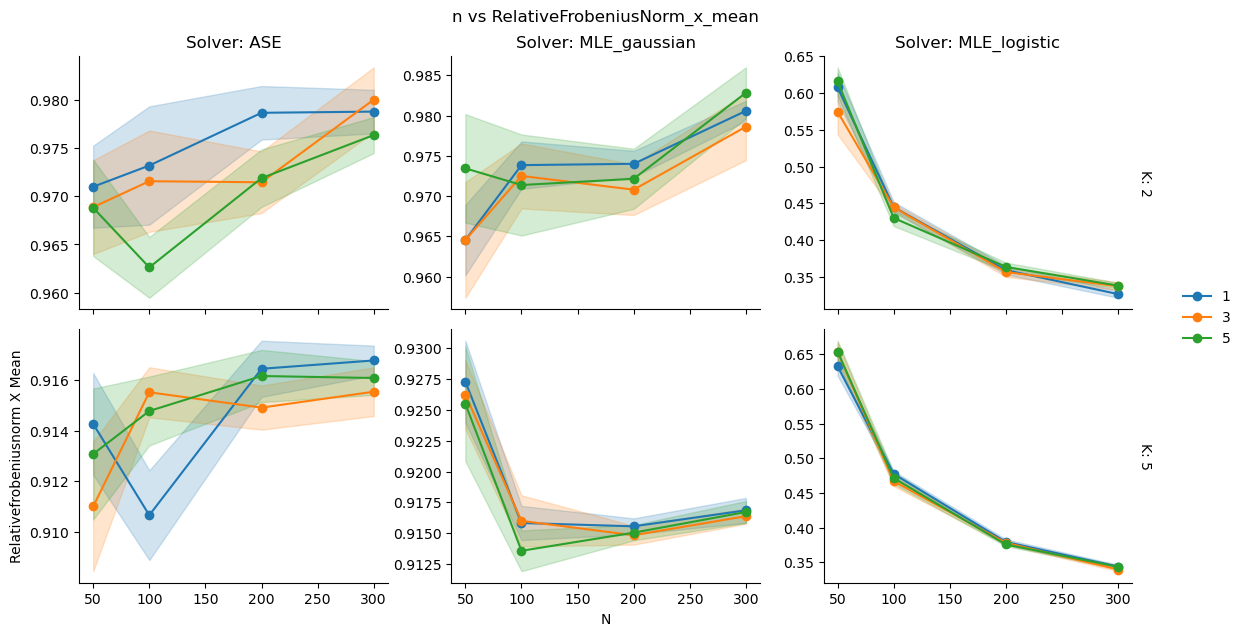

: 

: 

In [ ]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
    grouped_stats=agg_out_x_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=True,
)

plot_grid(
    grouped_stats=agg_out_x_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["edge_var", "solver", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
)

In [ ]:
1 / 0


def logistic_grad(params, X, y, mu=None):
    """Utility function for scipy optimizer returning loss and gradient for logistic regression"""
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w


def solve_logistic_scipy(X, y, mu=None):
    """Solve logistic regression with (possibly) fixed intercept and positive coefficients

    Parameters
    ----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target vector
    mu : float, optional
        Intercept term, by default None. If None estimate it

    Returns
    -------
    np.ndarray
        Coefficients of the logistic regression
    float
        Intercept term
    """

    n_samples, n_features = X.shape

    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(
            logistic_grad,
            initial_params,
            args=(X, y, mu),
            method="L-BFGS-B",
            bounds=bounds,
            jac=True,
        )

    return res.x[:n_features], res.x[-1] if mu is None else mu


def MLE_logistic(A, k=2, rng=None, shrink=0, **kwargs):
    # print("WARNING: MLE_logistic is experimental and might not work as expected.")
    """Maximum Likelihood Estimation for Logistic link adjacency matrix

    Parameters
    ----------
    A : np.ndarray
        Adjacency matrix
    k : int, optional
        Number of latent dimensions, by default 2
    rng : np.random.Generator, optional
        Random number generator, by default None
    shrink : int, optional
        Shrinkage parameter, by default 0

    Returns
    -------
    _type_
        _description_
    """
    if rng is None:
        rng = np.random.default_rng()

    # useful quantities
    n = A.shape[0]

    # in the paper it seems to use the frob norm NOT squared, i get better results
    # squaring it
    a_norm_scaled = 1 / (n * (n - 1)) * norm(A, "fro") ** 2

    # mean centered matrix
    A_centered = A - a_norm_scaled

    # from paper, mle of \mu
    mu_hat = -np.log(a_norm_scaled / (1 - a_norm_scaled))

    # use this to fix randomness in eigsh
    v0 = rng.standard_normal(size=A_centered.shape[0])

    evals, evectors = eigsh(A_centered, k=k, which="LM", v0=v0)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evectors = evectors[:, idx]

    # build the matrix of features
    X_big = np.zeros((n * (n - 1) // 2, k))

    for i in range(k):
        t = np.outer(evectors[:, i], evectors[:, i])
        X_big[:, i] = t[np.triu_indices(n, k=1)]

    # define as target the upper diagonal part of A (equal to lower since
    # A symmetric)
    target = A[np.triu_indices(n, k=1)]

    # solve logistic regression with fixed mu and positive constrained coefs
    coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    xhat = evectors * np.sqrt(coefs)

    return [xhat], [evals]

ZeroDivisionError: division by zero

: 

: 